-----

Video Game Sales Analysis

In [40]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats as st

In [41]:
df_games = pd.read_csv("games.csv")

In [42]:
df_games.info()
print(df_games.sample(10))
df_games.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB
                                                    Name Platform  \
7221                               NHL Championship 2000       PS   
6164        The Urbz: Sims In the City (US weekly sales)       DS   
15492  Crayon Shin-Chan: Uchuu de Achoo!? Yuujou 

np.int64(0)

Data Preparation and Cleaning

In [43]:
df_games.columns = df_games.columns.str.lower()
df_games = df_games.dropna(subset=["name"])

df_games["year_of_release"] = df_games["year_of_release"].astype("Int64")

df_games["user_score"] = df_games["user_score"].replace("tbd",np.nan)
df_games["user_score"] = pd.to_numeric(df_games["user_score"], errors='coerce')

df_games["rating"] = df_games["rating"].fillna("Unknown")

df_games["total_sales"] = df_games["na_sales"] + df_games["eu_sales"] + df_games["jp_sales"] + df_games["other_sales"]

df_games.info()

print(df_games[df_games["platform"]=="X360"]["total_sales"].sum())

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  str    
 11  total_sales      16713 non-null  float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 2.3 MB
971.4200000000001


Missing values in year_of_release were left unchanged because introducing values could affect future statistical measurements and hypothesis studies. I also changed the data type to integers, since years should be treated as whole numbers.

For user_score, I replaced tbd with missing values so the column could be converted to a suitable numeric type (Float64), since tbd and NaN are equivalent when no real value is available.

For rating, I used fillna with Unknown so the column could be handled as a string when needed. We can consider NaN equivalent to Unknown because it has no real value.

year_of_release
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


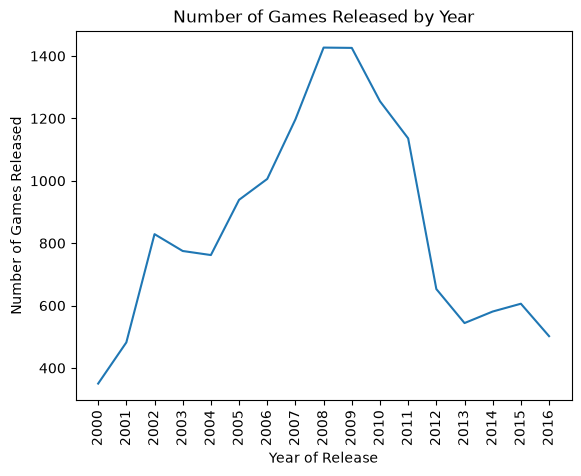

In [44]:
games_by_year = df_games.groupby("year_of_release")["name"].count()
                
games_by_year = games_by_year[games_by_year.index >= 2000]

print(games_by_year)

plt.plot(games_by_year.index, games_by_year.values)
plt.xticks(games_by_year.index, rotation=90)
plt.ylabel("Number of Games Released")
plt.xlabel("Year of Release")
plt.title("Number of Games Released by Year")
plt.show()


We can see that there is a large difference in the number of games released each year, especially from 2005 to 2011, when there was an increase of nearly 50% compared with the early 2000s, followed by a similar decline from 2012 to 2016. Here, we did not take the earlier data into account because the most relevant information comes from the more recent decade.

In [45]:
df_games = df_games[df_games["year_of_release"] >= 2000]

top_platform_sales = (df_games.groupby("platform")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
                          )
top_platforms = top_platform_sales.index

platforms_yearly = (df_games.groupby(["platform","year_of_release"])["total_sales"]
    .sum()
    .sort_values(ascending=False)
                          )
top_platforms_yearly = df_games[df_games["platform"].isin(top_platforms)]

top_platforms_yearly = top_platforms_yearly.groupby(["platform","year_of_release"])["total_sales"].sum()

top_platforms_yearly.unstack(level="platform")

platform,3DS,DS,GBA,PS2,PS3,PS4,PSP,Wii,X360,XB
year_of_release,,,,,,,,,,
2000,NaN,NaN,0.07,39.17,NaN,NaN,NaN,NaN,NaN,0.99
2001,NaN,NaN,61.53,166.43,NaN,NaN,NaN,NaN,NaN,22.26
2002,NaN,NaN,74.16,205.38,NaN,NaN,NaN,NaN,NaN,48.01
2003,NaN,NaN,56.67,184.31,NaN,NaN,NaN,NaN,NaN,55.04
2004,NaN,17.27,77.91,211.81,NaN,NaN,7.06,NaN,NaN,65.42
2005,NaN,130.14,33.86,160.66,NaN,NaN,43.84,NaN,8.25,49.08
2006,NaN,119.81,5.28,103.42,20.96,NaN,55.32,137.15,51.62,10.04
2007,NaN,146.94,3.40,75.99,73.19,NaN,46.93,152.77,95.41,0.55
2008,NaN,145.31,NaN,53.90,118.52,NaN,34.55,171.32,135.26,0.18



Here we have the platforms with the highest sales, which we can infer are the most popular. They appeared around 2000 for PS2 and the others between 2004 and 2006. Each platform remained in the market for roughly 10 to 12 years, but we can see sales begin to decline about 3 to 4 years before they disappear.

In [46]:

top_platform_sales = (df_games.groupby("platform")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
                     )

print(top_platform_sales)



platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.76
Name: total_sales, dtype: float64


For this analysis, PS2, X360, PS3, Wii, and DS were selected as the most relevant platforms because their sales greatly exceed those of the rest of the market, often doubling or even tripling the results of the platforms that follow them in the ranking. This allows the analysis to focus on the consoles with the greatest commercial impact.

When observing the temporal distribution of sales, it is clear that most of these platforms are in a decline phase and close to the end of their commercial lifecycle. The main exceptions are PS4, XOne, and WiiU, which correspond to more recent generations. Considering the historical behavior of the platforms analyzed, it is reasonable to project that PS4 and XOne will be the most profitable options in the coming years, since at the time of the analysis they had been on the market for only about three years. In addition, the observed trends indicate that consoles usually reach their peak sales between 3 and 5 years after launch, so both platforms still had room to continue growing before entering a decline phase.

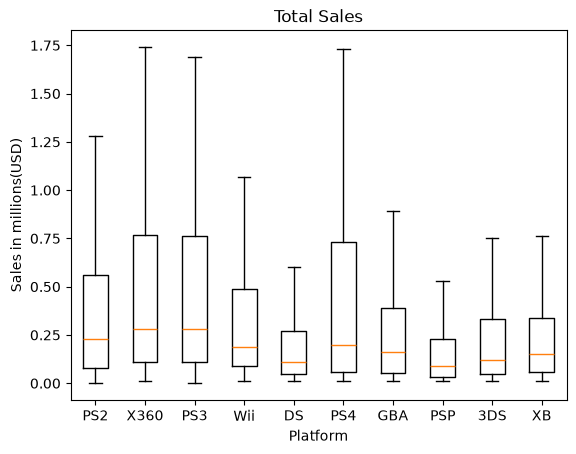

In [47]:
all_platform_sales = []

for plataforma in top_platforms:
    ventas = df_games[df_games["platform"] == plataforma]["total_sales"]
    all_platform_sales.append(ventas)




plt.boxplot(all_platform_sales, showfliers = False)
plt.title("Total Sales")
plt.xticks(range(1, len(top_platforms) + 1), top_platforms)
plt.ylabel("Sales in millions(USD)")
plt.xlabel("Platform")
plt.show()


We can see that the median sales of most platforms do not exceed $3 million, and they remain fairly similar across platforms. What does vary greatly is the upper whiskers and the third quartiles of the boxes, because there is a large dispersion across the dataset.

From this, we can infer that some platforms can generate very strong sales from a small number of titles, such as X360, PS3, and PS4, while others do not sell as much per individual title but instead accumulate sales across a large number of titles, such as PS2, Wii, and DS.


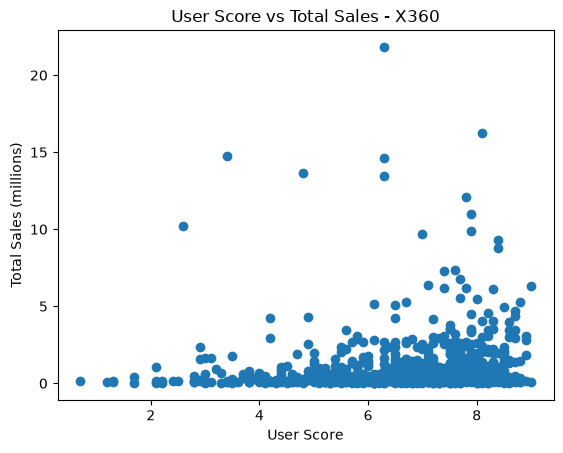

             user_score  total_sales
user_score     1.000000     0.114187
total_sales    0.114187     1.000000


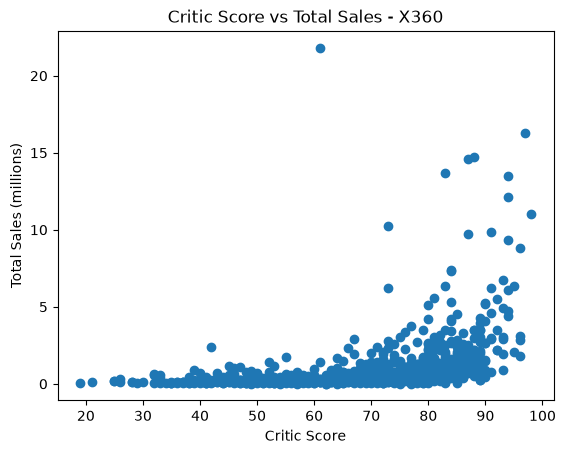

              critic_score  total_sales
critic_score      1.000000     0.392866
total_sales       0.392866     1.000000


In [48]:


x360 = df_games[df_games["platform"] == "X360"]

x360_user_score = x360.dropna(subset=["user_score"])

x360_critic_score =  x360.dropna(subset=["critic_score"])



plt.scatter(x360_user_score["user_score"],x360_user_score["total_sales"])
plt.xlabel("User Score")
plt.ylabel("Total Sales (millions)")
plt.title("User Score vs Total Sales - X360")
plt.show()

print(x360_user_score[["user_score","total_sales"]].corr())

plt.scatter(x360_critic_score["critic_score"],x360_critic_score["total_sales"])
plt.xlabel("Critic Score")
plt.ylabel("Total Sales (millions)")
plt.title("Critic Score vs Total Sales - X360")
plt.show()

print(x360_critic_score[["critic_score","total_sales"]].corr())

Based on the analysis, we can conclude that there is no significant correlation between user ratings and video game sales, since the data are highly dispersed and do not show a clear trend indicating that higher scores translate into higher sales.

On the other hand, in the case of critic scores, a positive correlation with sales is observed. Although this relationship is only moderately relevant, the results suggest that the perception of specialized critics may have some influence on a game’s commercial performance. For this reason, it would be advisable to conduct a deeper analysis to determine whether this relationship can be used as a predictive variable in future studies or as support for decision-making in the industry.

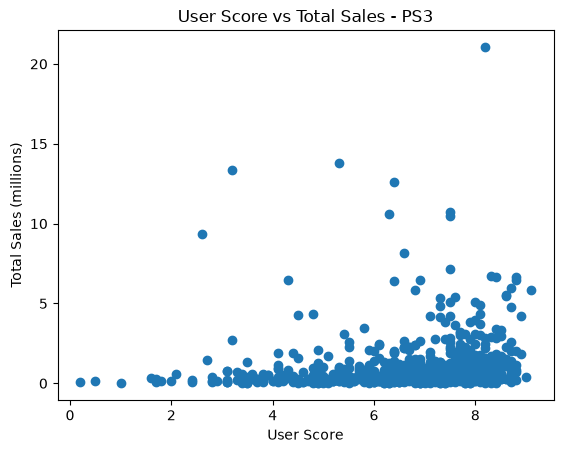

             user_score  total_sales
user_score     1.000000     0.128416
total_sales    0.128416     1.000000


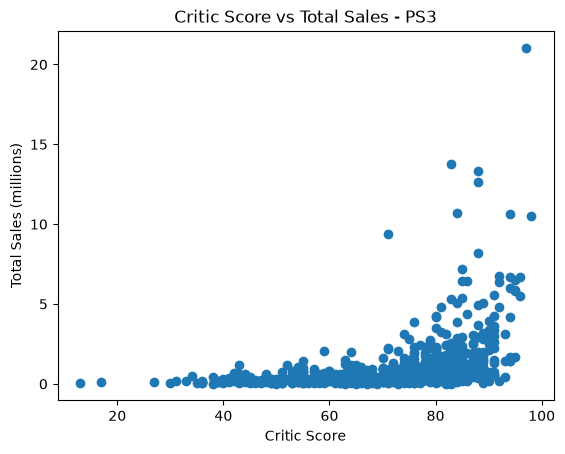

              critic_score  total_sales
critic_score      1.000000     0.432759
total_sales       0.432759     1.000000


In [49]:

ps3 = df_games[df_games["platform"] == "PS3"]

ps3_user_score = ps3.dropna(subset=["user_score"])

ps3_critic_score =  ps3.dropna(subset=["critic_score"])



plt.scatter(ps3_user_score["user_score"],ps3_user_score["total_sales"])
plt.xlabel("User Score")
plt.ylabel("Total Sales (millions)")
plt.title("User Score vs Total Sales - PS3")
plt.show()

print(ps3_user_score[["user_score","total_sales"]].corr())

plt.scatter(ps3_critic_score["critic_score"],ps3_critic_score["total_sales"])
plt.xlabel("Critic Score")
plt.ylabel("Total Sales (millions)")
plt.title("Critic Score vs Total Sales - PS3")
plt.show()

print(ps3_critic_score[["critic_score","total_sales"]].corr())


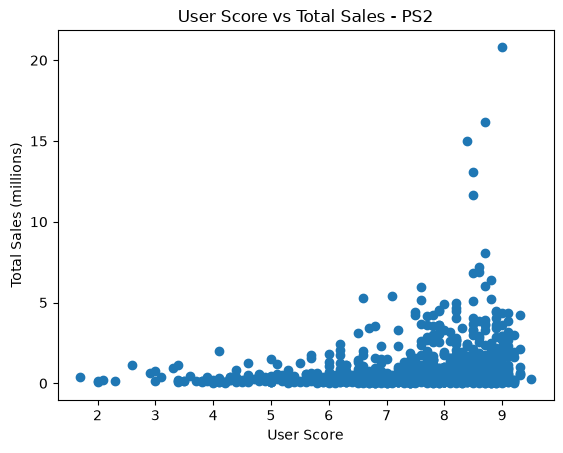

             user_score  total_sales
user_score     1.000000     0.175055
total_sales    0.175055     1.000000


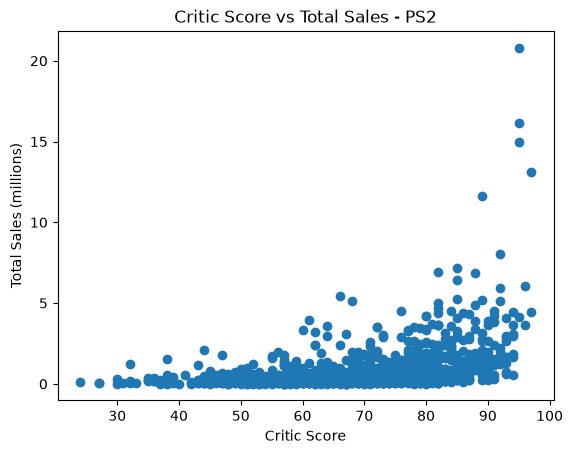

              critic_score  total_sales
critic_score      1.000000     0.392536
total_sales       0.392536     1.000000


In [50]:
ps2 = df_games[df_games["platform"] == "PS2"]

ps2_user_score = ps2.dropna(subset=["user_score"])

ps2_critic_score =  ps2.dropna(subset=["critic_score"])



plt.scatter(ps2_user_score["user_score"],ps2_user_score["total_sales"])
plt.xlabel("User Score")
plt.ylabel("Total Sales (millions)")
plt.title("User Score vs Total Sales - PS2")
plt.show()

print(ps2_user_score[["user_score","total_sales"]].corr())

plt.scatter(ps2_critic_score["critic_score"],ps2_critic_score["total_sales"])
plt.xlabel("Critic Score")
plt.ylabel("Total Sales (millions)")
plt.title("Critic Score vs Total Sales - PS2")
plt.show()

print(ps2_critic_score[["critic_score","total_sales"]].corr())


Now, comparing the correlation for the PS2 and PS3 platforms, we can see that they behave in almost the same way. The difference in correlation is minimal compared with the other measurements, which suggests that score does not significantly affect game sales and that this pattern is fairly consistent across most platforms.

genre
Action          1526.16
Sports          1130.92
Shooter          912.70
Role-Playing     731.22
Misc             718.35
Racing           561.06
Platform         494.42
Simulation       335.41
Fighting         311.90
Adventure        183.74
Name: total_sales, dtype: float64


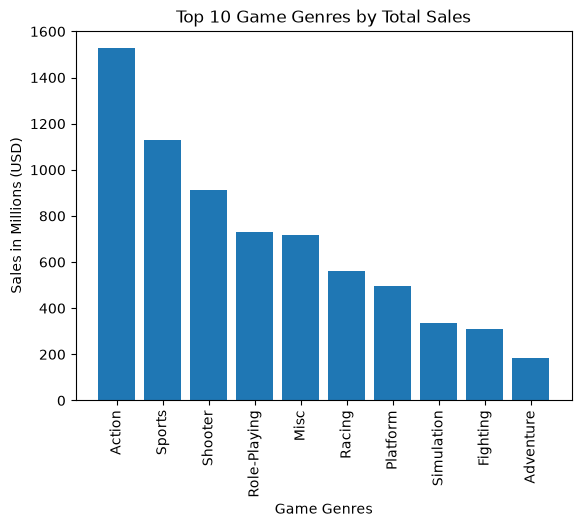

In [51]:

top_genres_sales = (df_games.groupby("genre")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
                  )
print(top_genres_sales)

top_genres = top_genres_sales.index

plt.bar(top_genres,top_genres_sales)
plt.xticks(rotation=90)
plt.ylabel("Sales in Millions (USD)")
plt.xlabel("Game Genres")
plt.title("Top 10 Game Genres by Total Sales")
plt.show()


The results show that Action games overwhelmingly lead the market, accumulating approximately 1,526 million dollars in sales. This genre exceeds Sports, its closest competitor, by about 400 million dollars, which shows a clear consumer preference for this type of title. Likewise, Sports and Shooter also perform exceptionally well, with sales far above those of the other categories, making them highly profitable segments within the industry.

In contrast, Adventure games record the lowest sales volume, with a difference of more than 1,200 million dollars compared with Action. Similarly, Simulation and Fighting games show significantly lower results, placing more than 1,000 million dollars below the two leading genres. These results suggest lower relative demand for these categories, making them segments with more limited commercial potential compared with the dominant genres.


          na_sales  eu_sales  jp_sales
platform                              
X360        595.74    268.32       NaN
PS2         572.92    332.63    137.54
Wii         486.87    258.32       NaN
PS3         390.13    327.21     79.41
DS          380.31    188.41    175.00
3DS            NaN       NaN    100.62
PSP            NaN       NaN     75.88


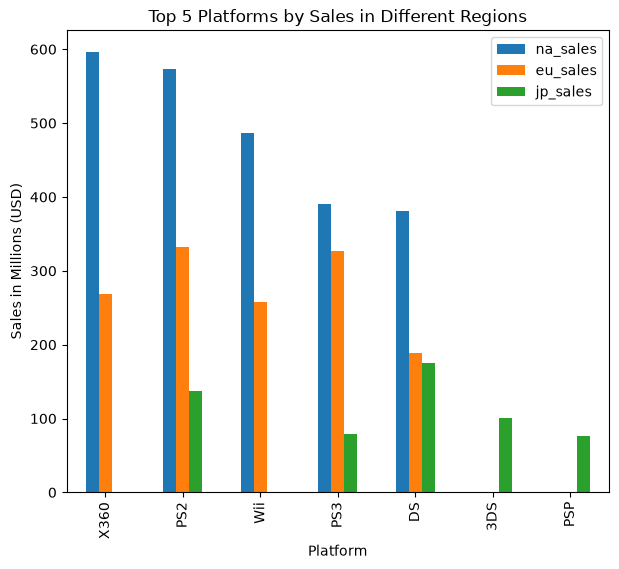

In [60]:
regions = df_games[["na_sales","eu_sales","jp_sales"]]

sales_regions = []

for region in regions:
    sales = df_games.groupby("platform")[region].sum().sort_values(ascending=False).head()
    sales.name = region
    sales_regions.append(sales)

sales_regions = pd.concat(sales_regions, axis=1)

print(sales_regions)

sales_regions.plot(kind='bar', figsize=(7,6))
plt.xticks(rotation=90)
plt.ylabel("Sales in Millions (USD)")
plt.xlabel("Platform")
plt.title("Top 5 Platforms by Sales in Different Regions")
plt.show()

The distribution of sales by platform shows clear differences between regions. In North America, X360 and PS2 dominate, while in Europe PS2 and PS3 lead, reflecting a stronger preference for Sony consoles. On the other hand, Japan shows a different pattern, with DS as the best-selling platform and a strong presence of handheld consoles such as 3DS and PSP. Overall, although some platforms maintain solid global performance, consumer preferences vary significantly by region.

              na_sales  eu_sales  jp_sales
genre                                     
Action          752.27    466.58    132.23
Sports          589.39    339.58     75.88
Shooter         495.23    294.02       NaN
Misc            365.27    196.71     85.43
Role-Playing    282.30       NaN    241.71
Racing             NaN    192.02       NaN
Platform           NaN       NaN     55.27


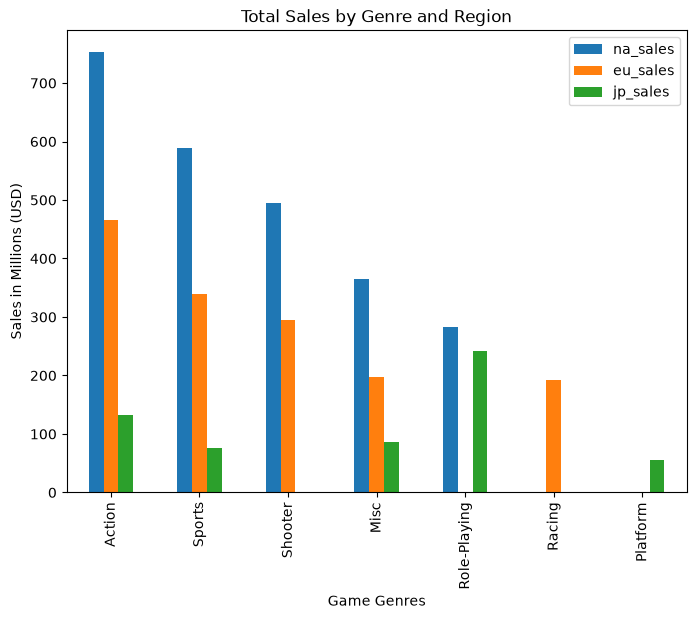

In [61]:
genre_sales_regions = []

for region in regions:
    sales = df_games.groupby("genre")[region].sum().sort_values(ascending=False).head()
    sales.name = region
    genre_sales_regions.append(sales)

genre_sales_regions = pd.concat(genre_sales_regions, axis=1)

print(genre_sales_regions)

genre_sales_regions.plot(kind='bar', figsize=(8, 6))
plt.ylabel("Sales in Millions (USD)")
plt.xlabel("Game Genres")
plt.title("Total Sales by Genre and Region")
plt.show()

Sales by genre show distinct regional preferences. In both North America and Europe, Action and Sports are the top-selling genres, followed by Shooter, which indicates a similar trend in both Western markets. In contrast, Japan shows a clear preference for Role-Playing games, far surpassing the rest of the genres. These results suggest that consumer tastes vary by region, especially between Western markets and Japan.

         na_sales  eu_sales  jp_sales
rating                               
E         1249.26    690.61    189.91
M          727.80    472.40     57.84
T          709.86    392.71    131.01
Unknown    494.40    345.81    396.86
E10+       345.50    183.33     40.20


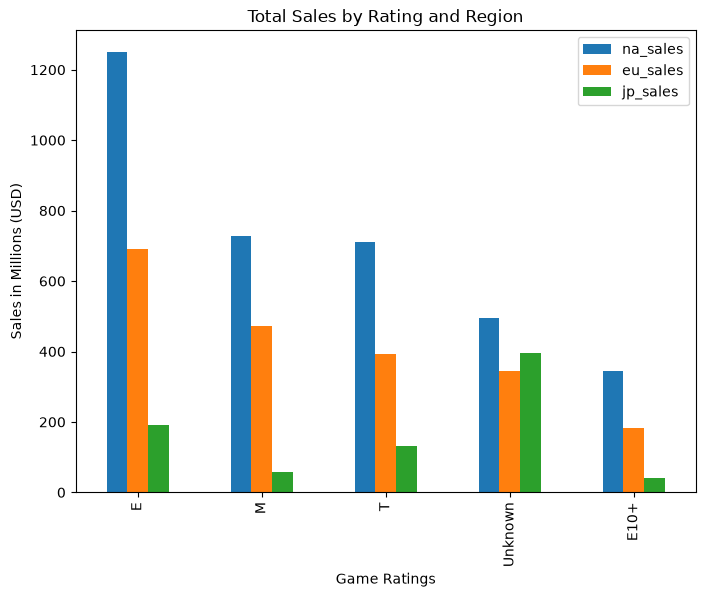

In [63]:
regions = df_games[["na_sales","eu_sales","jp_sales"]]

rating_regions = []

for region in regions:
    sales = df_games.groupby("rating")[region].sum().sort_values(ascending=False).head()
    sales.name = region
    rating_regions.append(sales)

sales_regions = pd.concat(rating_regions, axis=1)

print(sales_regions)

sales_regions.plot(kind='bar', figsize=(8, 6))
plt.ylabel("Sales in Millions (USD)")
plt.xlabel("Game Ratings")
plt.title("Total Sales by Rating and Region")
plt.show()

The analysis by ESRB rating shows that games rated E (Everyone) account for the highest sales in North America and Europe, suggesting strong demand for titles aimed at broad audiences. The M (Mature) and T (Teen) categories also perform strongly in both regions. In Japan, the Unknown category leads sales, followed by E and T, which may reflect differences in the rating systems used or the absence of ESRB information for a significant share of titles sold in that market. Overall, the results show clear regional differences in the distribution of sales by video game rating.

Hypothesis

In [55]:
xbox_one = df_games[df_games["platform"] == "XOne"].dropna(subset=["user_score"])["user_score"]
pc = df_games[df_games["platform"] == "PC"].dropna(subset=["user_score"])["user_score"]

st.ttest_ind(xbox_one,pc)

TtestResult(statistic=np.float64(-4.14273278153197), pvalue=np.float64(3.7501857224173426e-05), df=np.float64(914.0))


"There is sufficient statistical evidence to say that user ratings on Xbox One and PC are significantly different."
The platforms do influence user ratings, since the difference between Xbox One and PC is not due to chance.


In [56]:
accion = df_games[df_games["genre"] == "Action"].dropna(subset=["user_score"])["user_score"]

sports = df_games[df_games["genre"] == "Sports"].dropna(subset=["user_score"])["user_score"]


st.ttest_ind(accion,sports)

TtestResult(statistic=np.float64(1.6926269778062475), pvalue=np.float64(0.09063548503578983), df=np.float64(2858.0))

"The average user_score of Action and Sports games is the same (there is no significant difference between them)."
"There is not enough statistical evidence to say that the average user ratings differ between the Action and Sports genres. The observed difference could be due to chance."

Final Conclusion

The analysis shows that the video game market is dominated by a small number of platforms, with PS2, X360, PS3, Wii, and DS being the most successful in terms of sales. However, historical trends suggest that PS4 and XOne represent the best growth opportunities because they were still in the early stages of their lifecycle during the period analyzed.

The Action, Sports, and Shooter genres account for most sales, while genres such as Adventure, Simulation, and Fighting show considerably lower commercial performance. In addition, important regional differences were identified, with different preferences for platforms, genres, and ratings across North America, Europe, and Japan.

Regarding ratings, no significant relationship was found between user scores and video game sales. In contrast, critic scores show a moderately positive correlation, suggesting that they may have some influence on a title’s commercial performance.

Finally, the hypothesis tests provided additional evidence about user behavior. The comparison between Xbox One and PC user ratings showed statistically significant differences (p < 0.05), indicating that the platform does influence player perception. On the other hand, the comparison between Action and Sports genres did not show significant differences (p > 0.05), so both genres receive similar ratings from users.

Overall, the results indicate that the commercial success of a video game is more closely related to factors such as platform, genre, and regional preferences than to user ratings, providing valuable information for decision-making in the industry.